<a href="https://colab.research.google.com/github/Ashuralotus/Ashuralotus1/blob/main/NeuralNetwork_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
df.shape

(45646, 31)

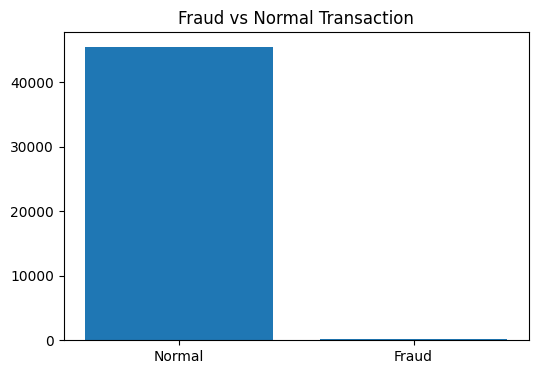

In [6]:
fraud = df['Class'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(['Normal','Fraud'], fraud)

plt.title('Fraud vs Normal Transaction')

plt.show()

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [11]:
model = Sequential([
    Input(shape=(30,)),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9407 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 2/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 3/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 4/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 5/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 6/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 7/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 8/10
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9969 - loss: nan - val_accuracy: 0.9973 - val_loss: nan
Epoch 9/10
457/457 ━━━━━

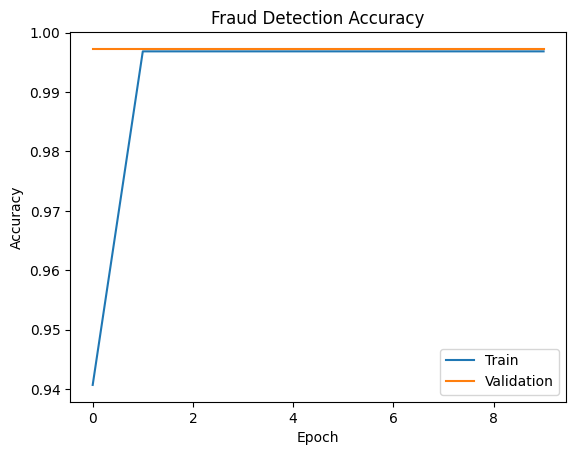

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Fraud Detection Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()